In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

In [2]:
train_df = pd.read_csv("creditcard.csv")

prod_files = ["../drift_1.csv", "../drift_2.csv", "../drift_3.csv", "../drift_4.csv", "../drift_5.csv"]
prod_dfs   = [pd.read_csv(f) for f in prod_files]

FEATURES = joblib.load("feature_list.pkl")

In [3]:
# The KS test compares two distributions and returns:
#   statistic — how different they are (0 = identical, 1 = completely different)
#   p-value   — probability this difference happened by chance
#               p < 0.05 means the drift is statistically significant

def run_ks_tests(train, prod_list, features):
    results = []
    for i, prod in enumerate(prod_list):
        for feat in features:
            stat, p = stats.ks_2samp(train[feat].dropna(), prod[feat].dropna())
            results.append({
                "dataset":   f"Prod {i+1}",
                "feature":   feat,
                "ks_stat":   round(stat, 4),
                "p_value":   round(p, 4),
                "drifted":   p < 0.05
            })
    return pd.DataFrame(results)

ks_results = run_ks_tests(train_df, prod_dfs, FEATURES)

In [4]:
# PSI buckets a feature into 10 bins and compares proportions
#   PSI < 0.1  → stable
#   0.1 – 0.2  → monitor
#   PSI > 0.2  → significant drift

def compute_psi(expected, actual, bins=10):
    # Build bins from the expected (training) distribution
    breakpoints = np.linspace(0, 100, bins + 1)
    expected_perc = np.percentile(expected, breakpoints)
    expected_perc = np.unique(expected_perc)  # remove duplicate edges

    # Count what proportion falls in each bin
    def bucket(data, edges):
        counts = np.histogram(data, bins=edges)[0]
        proportions = counts / len(data)
        proportions = np.where(proportions == 0, 1e-6, proportions)  # avoid log(0)
        return proportions

    exp_props = bucket(expected, expected_perc)
    act_props = bucket(actual,   expected_perc)

    # PSI formula
    psi = np.sum((act_props - exp_props) * np.log(act_props / exp_props))
    return round(psi, 4)

def run_psi(train, prod_list, features):
    results = []
    for i, prod in enumerate(prod_list):
        for feat in features:
            psi = compute_psi(train[feat].dropna().values,
                              prod[feat].dropna().values)
            results.append({
                "dataset": f"Prod {i+1}",
                "feature": feat,
                "psi":     psi,
                "level":   "stable"    if psi < 0.1
                           else "monitor"  if psi < 0.2
                           else "drifted"
            })
    return pd.DataFrame(results)

psi_results = run_psi(train_df, prod_dfs, FEATURES)

In [5]:
print("── KS Test: Drifted Features (p < 0.05) ────────")
ks_drifted = ks_results[ks_results["drifted"] == True]
print(ks_drifted.groupby("dataset")["feature"].count().rename("drifted_features"))

print("\n── PSI: Significantly Drifted Features (PSI > 0.2) ──")
psi_drifted = psi_results[psi_results["level"] == "drifted"]
print(psi_drifted.groupby("dataset")[["feature", "psi"]].apply(
    lambda x: x.sort_values("psi", ascending=False).head(5)
))

── KS Test: Drifted Features (p < 0.05) ────────
dataset
Prod 1    30
Prod 2    29
Prod 3    30
Prod 4    30
Prod 5    29
Name: drifted_features, dtype: int64

── PSI: Significantly Drifted Features (PSI > 0.2) ──
            feature     psi
dataset                    
Prod 1  0      Time  2.6133
        28      V28  0.9336
        8        V8  0.8765
        20      V20  0.8310
        27      V27  0.8211
Prod 2  59   Amount  2.7402
        30     Time  2.6156
        58      V28  0.9331
        38       V8  0.8617
        57      V27  0.8037
Prod 3  60     Time  2.6399
        88      V28  0.9506
        68       V8  0.8727
        80      V20  0.8420
        87      V27  0.8170
Prod 4  90     Time  2.6456
        118     V28  0.9527
        98       V8  0.8555
        117     V27  0.8137
        110     V20  0.7993
Prod 5  120    Time  2.6432
        148     V28  0.9446
        128      V8  0.8475
        140     V20  0.8168
        147     V27  0.8081


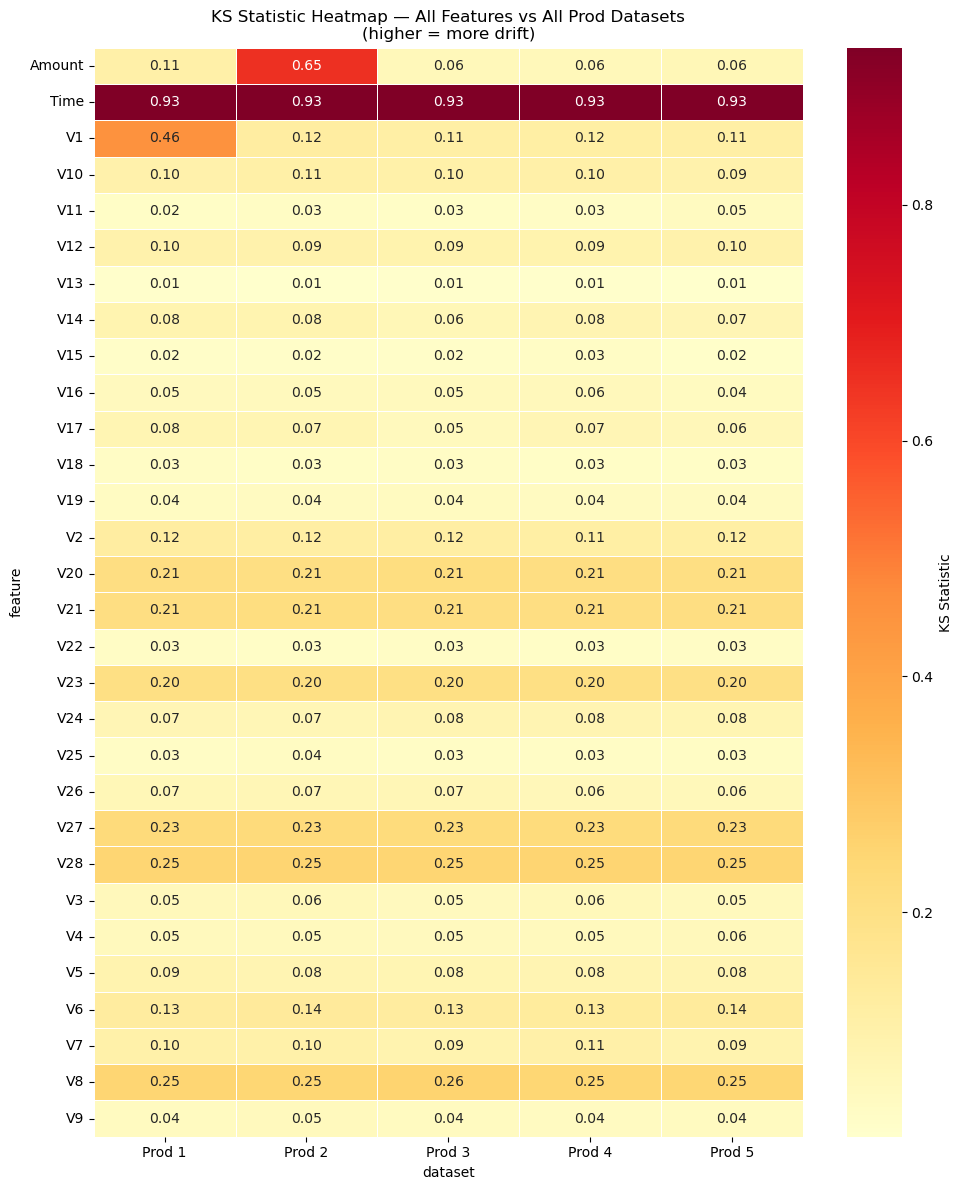

In [6]:
ks_pivot = ks_results.pivot(index="feature", columns="dataset", values="ks_stat")

plt.figure(figsize=(10, 12))
sns.heatmap(ks_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "KS Statistic"})
plt.title("KS Statistic Heatmap — All Features vs All Prod Datasets\n(higher = more drift)")
plt.tight_layout()
plt.show()

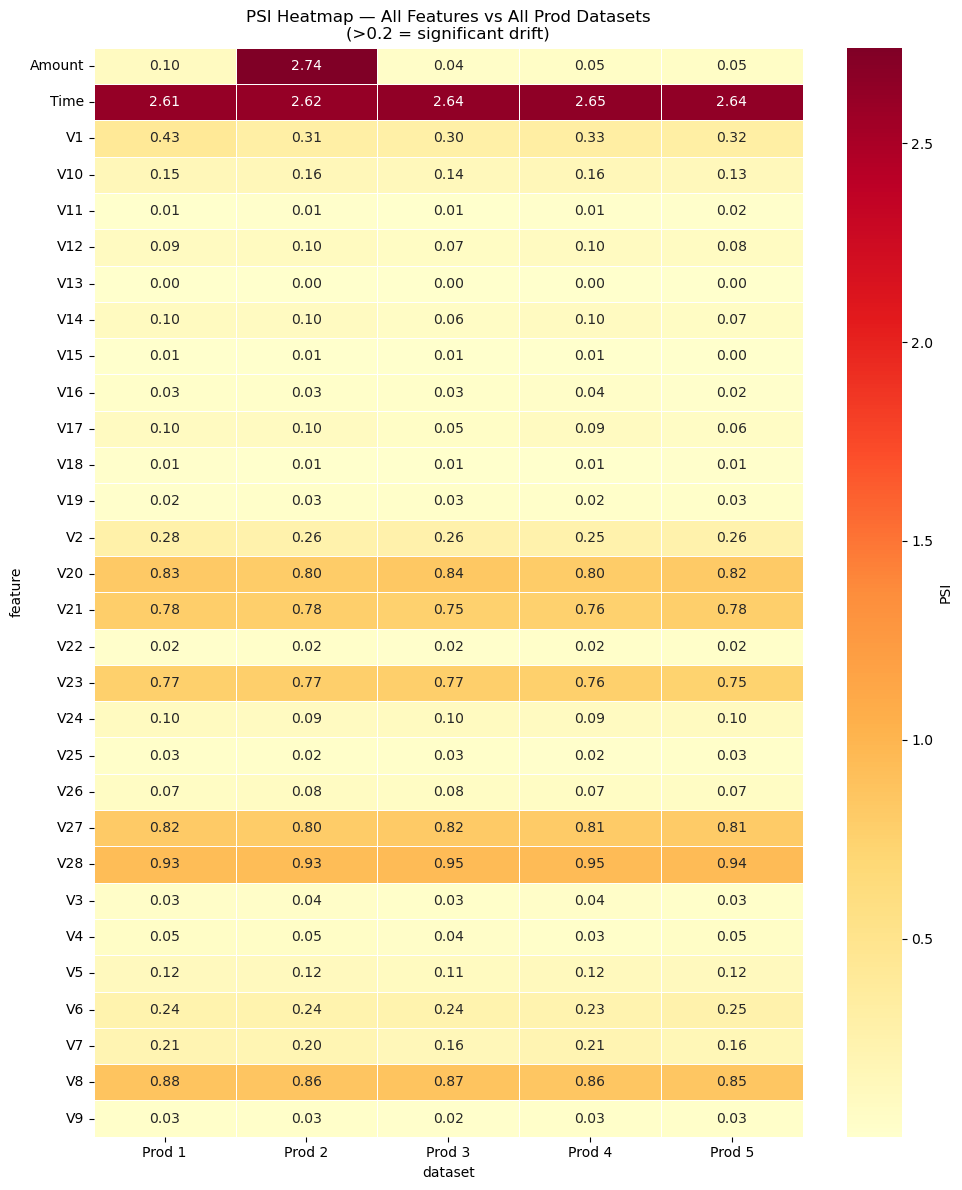

In [7]:
psi_pivot = psi_results.pivot(index="feature", columns="dataset", values="psi")

plt.figure(figsize=(10, 12))
sns.heatmap(psi_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "PSI"})
plt.title("PSI Heatmap — All Features vs All Prod Datasets\n(>0.2 = significant drift)")
plt.tight_layout()
plt.show()

In [8]:
ks_results.to_csv("ks_results.csv",  index=False)
psi_results.to_csv("psi_results.csv", index=False)
print("\nDrift results saved.")


Drift results saved.
